In [1]:
import numpy as np

from classes.rate import Rate
from classes.species import Gene, Signal

from Importables.param_sweep import run_param_sweep, create_param_grid
from Importables.interaction_matrix import build_interaction_matrix

# Colony Simulation and Parameter Sweep

Using a user-specified signalling interaction matrix, simulate multicellular colonies across a defined range of model parameters. Each simulation captures how cell-cell signalling influences the possible cell states, allowing us to characterize how changes in signalling strength and other parameters affect emergent cellular phenotypes.

## 1. Define rates for each gene and signal

In [ ]:
# k1 represents the rate of gene expression
# k2 represents the rate of signal production
k1 = Rate('k1', lower_bound=1, upper_bound=6)
k2 = Rate('k2', lower_bound=1, upper_bound=1)
param_list = [k1, k2]

## 2. Define each gene and signal in the system

In [3]:
n_genes = 3
gene_list = [Gene(f"g{i+1}", k1, basal=0) for i in range(n_genes)]
signal_list = [Signal(f"s{i+1}", k2, basal=0) for i in range(n_genes)]

## 3. Define interaction matrix

In [4]:
gene_to_gene = np.array([
    [ 0, -1, -1], # g1 represses g2, g3
    [ -1,  0, -1],  # g2 represses g1, g3
    [ -1, -1,  0]   # g3 represses g1, g2
])

gene_to_signal = np.array([
    [ 1, 0, 0], # g1 activates s1
    [ 0, 1, 0],  # g2 activates s2
    [ 0, 0, 1]   # g3 activates s3
])

signal_to_gene = np.array([
    [ 1, 0, 0], # s1 activates g1
    [ 0, 1, 0],  # s2 activates g2
    [ 0, 0, 1]   # s3 activates g3
])


In [5]:
interaction_matrix = build_interaction_matrix(gene_to_gene, gene_to_signal, signal_to_gene)

## 4. Create parameter grid for sweep

In [6]:
param_grid = create_param_grid(param_list, n_samples=20)

## 5. Simulate

In [7]:
T_final = 250
euler_step_size = 0.2
n_cells = 10 # per colony
num_ics = 50

In [8]:
adata = run_param_sweep(param_grid, param_list, n_cells, num_ics, gene_list, interaction_matrix, signal_list, T_final, euler_step_size)

Running parameter sweep: 100%|██████████| 20/20 [02:58<00:00,  8.93s/it]


In [9]:
adata 

AnnData object with n_obs × n_vars = 12520000 × 3
    obs: 'time', 'cell_id', 'signal_s1', 'signal_s2', 'signal_s3', 'initial_condition', 'param_set_id', 'sample_id', 'k1', 'k2'

## 6. Analysis of final cell states

In [10]:
import scanpy as sc
from sklearn.cluster import KMeans

In [11]:
adata_f = adata[np.isclose(adata.obs['time'], T_final)]
adata_f

View of AnnData object with n_obs × n_vars = 10000 × 3
    obs: 'time', 'cell_id', 'signal_s1', 'signal_s2', 'signal_s3', 'initial_condition', 'param_set_id', 'sample_id', 'k1', 'k2'

In [12]:
sc.pp.normalize_total(adata_f)
sc.pp.log1p(adata_f)

/opt/anaconda3/envs/F2025_DS/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/F2025_DS/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [13]:
sc.tl.pca(adata_f)

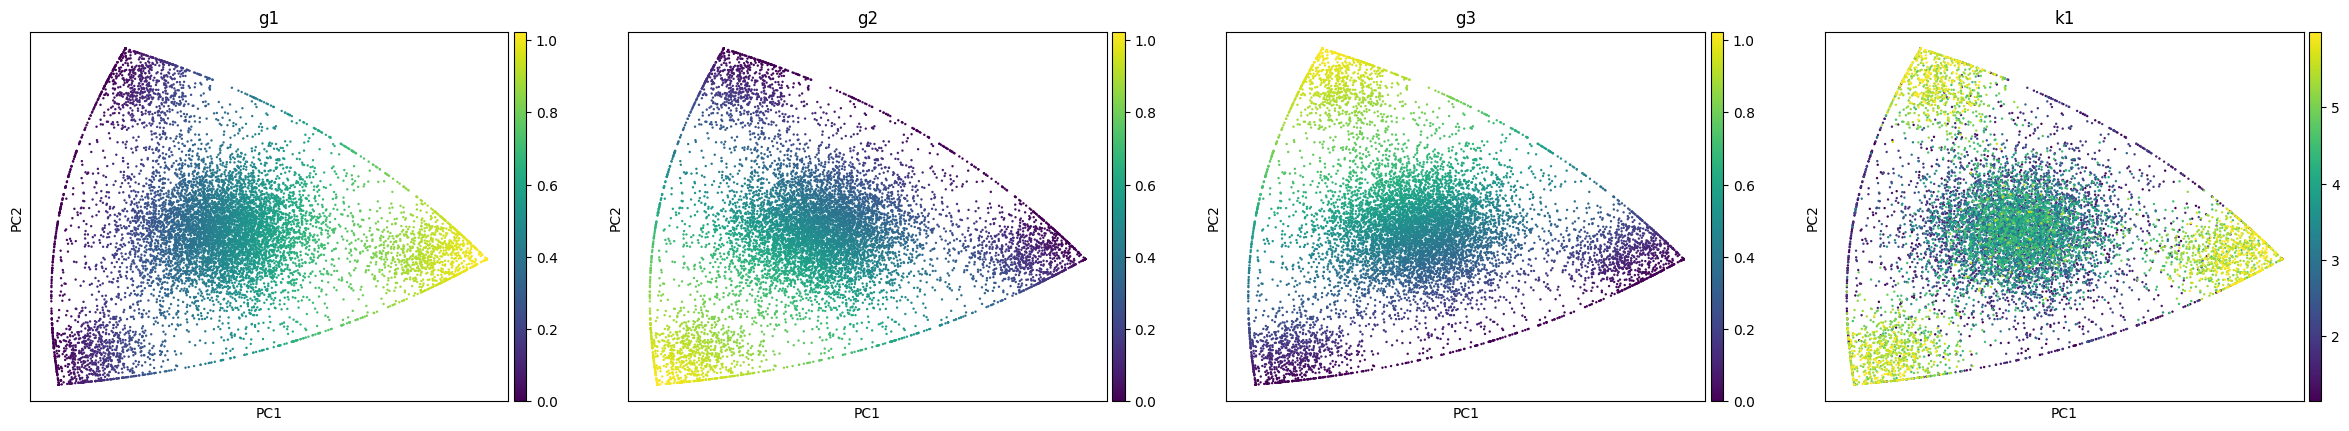

In [14]:
# Visualize attractors

sc.pl.pca(
    adata_f,
    color=['g1', 'g2', 'g3', 'k1'],
)

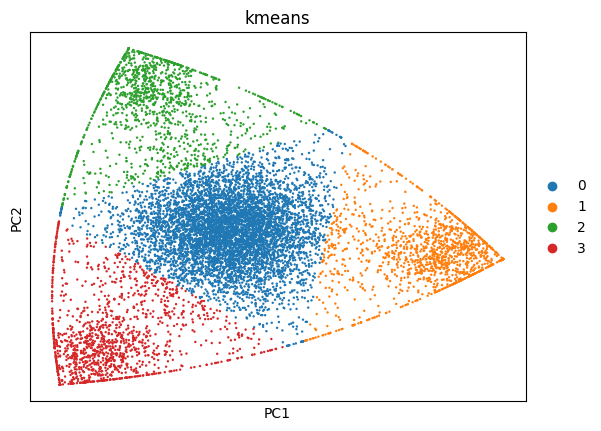

In [16]:
# Clustering using K-means
X_embed = adata_f.obsm['X_pca']

kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto')
kmeans.fit(X_embed)

adata_f.obs['kmeans'] = kmeans.labels_.astype(str)

sc.pl.pca(
    adata_f,
    color=['kmeans'],
)